In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
include("../scripts/TesselationCore.jl")
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end


  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

import .TesselationCore


In [3]:

export BVH, BVHTree, BVHLeaf, BVHNode

abstract type BVHTree end

struct BVHLeaf <: BVHTree
    data::Vector{Int}
end

struct BVHNode <: BVHTree
    depth::Int
    leftChild::BVHTree 
    rightChild::BVHTree
end


struct BVH
    tree::BVHTree
    bbox::Matrix{Float64}   
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix)
    indices = 1:size(boxes,2)
    return generateBVHTree(boxes,depth,limBox,indices)
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix, indices)
    
    if depth == 0 || size(boxes,2) < 2 
        if depth!=0
            println("Nontrivial leaf $depth") #REMOVE BEFORE PROD
        end
        return BVHLeaf(indices)
    end
    
    ax = depth%3 + 1

    mins = boxes[ax,indices,1]
    maxs = boxes[ax,indices,2]
    
    line = (limBox[ax,2]+limBox[ax,1])/2 

    leftIDs = indices[mins .≤ line]
    rightIDs = indices[maxs .≥ line]

    leftBox = copy(limBox)
    leftBox[ax,2] = line
    
    rightBox = copy(limBox)
    rightBox[ax,1] = line

    return BVHNode(depth,
    generateBVHTree(boxes,depth-1,leftBox,leftIDs), 
    generateBVHTree(boxes,depth-1,rightBox,rightIDs))
end


function BVH(data::Array,depth::Int,box::Matrix)
    boxes = cat(minimum(data,dims=3),maximum(data,dims=3),dims=3)
    tree = generateBVHTree(boxes,depth,box)
    return BVH(tree,box)
end

function BVH(data::Array,depth::Int)
    boxes = cat(minimum(data,dims=3),maximum(data,dims=3),dims=3)
    box = hcat(minimum(boxes[:,:,1],dims=2),maximum(boxes[:,:,2],dims=2))
    tree = generateBVHTree(boxes,depth,box)
    return BVH(tree,box)
end


BVH

In [4]:
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:100]

coords, tets = TesselationCore.tesselate(points3d)
tes = TesselationCore.Triangulation3D(points3d,tets')

simplices = coords[:,tets]

bvh = BVH(simplices,5)



BVH(BVHNode(5, BVHNode(4, BVHNode(3, BVHNode(2, BVHNode(1, BVHLeaf([7, 46, 55, 58, 60, 61, 63, 65, 68, 69  …  483, 487, 488, 490, 505, 506, 507, 508, 509, 512]), BVHLeaf([5, 7, 9, 26, 27, 28, 32, 34, 55, 58  …  465, 467, 468, 472, 483, 487, 488, 490, 507, 509])), BVHNode(1, BVHLeaf([1, 7, 10, 25, 43, 46, 48, 53, 58, 59  …  487, 488, 490, 498, 499, 505, 506, 507, 508, 512]), BVHLeaf([1, 5, 7, 9, 10, 26, 27, 28, 32, 34  …  465, 467, 468, 472, 483, 484, 487, 488, 490, 507]))), BVHNode(2, BVHNode(1, BVHLeaf([2, 13, 214, 229, 266, 267, 293, 300, 301, 302  …  503, 504, 505, 506, 507, 508, 509, 510, 511, 512]), BVHLeaf([2, 13, 57, 113, 121, 133, 139, 214, 226, 229  …  489, 490, 491, 494, 495, 496, 507, 509, 510, 511])), BVHNode(1, BVHLeaf([2, 10, 13, 17, 25, 59, 108, 109, 110, 214  …  502, 503, 504, 505, 506, 507, 508, 510, 511, 512]), BVHLeaf([2, 10, 13, 17, 35, 42, 57, 59, 80, 84  …  490, 491, 492, 493, 494, 495, 496, 507, 510, 511])))), BVHNode(3, BVHNode(2, BVHNode(1, BVHLeaf([5, 9, 18, 2

In [5]:
function standardEstimator(points, weights, depth = 9)

    coords, tets = TesselationCore.tesselate(points)
    tes = TesselationCore.Triangulation3D(points,tets',weights)

    simplices = coords[:,tets]
    bvh = BVH(simplices,depth)

    return bvh,tes,tets
end


function standardEstimator(points,depth = 9)

    coords, tets = TesselationCore.tesselate(points)
    tes = TesselationCore.Triangulation3D(points,tets')

    simplices = coords[:,tets]
    bvh = BVH(simplices,depth)

    return bvh,tes,tets
end



standardEstimator (generic function with 3 methods)

In [6]:
function recursiveSearch(point,leaf::BVHLeaf,bbox::Matrix) 
    return leaf.data 
end

function recursiveSearch(point,tree::BVHNode,bbox::Matrix)
    ax = tree.depth%3 + 1

    newBox = copy(bbox)

    line = (bbox[ax,2]+bbox[ax,1])/2
    if point[ax]<line
        newBox[ax,2] = line
        return recursiveSearch(point,tree.leftChild,newBox)
    end
    newBox[ax,1] = line
    return recursiveSearch(point,tree.rightChild,newBox)
end



pt = (rand(3))

ids = recursiveSearch(pt,bvh.tree,bvh.bbox)
neighbors = simplices[:,ids,:]


3×115×4 Array{Float64, 3}:
[:, :, 1] =
 0.0378932  0.279115  0.186465  0.18933   …  0.724078  0.540496  0.540496
 0.562739   0.562664  0.507706  0.750264     0.700268  0.278341  0.278341
 0.66955    0.612352  0.233641  0.617597     0.631825  0.588997  0.588997

[:, :, 2] =
 0.107155  0.382842  0.287496  0.0378932  …  0.381115  0.440576  0.440576
 0.921664  0.553942  0.57094   0.562739      0.599605  0.555523  0.555523
 0.530644  0.995568  0.269737  0.66955       0.403516  0.595538  0.595538

[:, :, 3] =
 0.0166606  0.148884  0.18933   0.279115  …  0.765741  0.737353  0.706005
 0.999105   0.533301  0.750264  0.562664     0.930335  0.367052  0.432694
 0.702731   0.897527  0.617597  0.612352     0.358826  0.489505  0.655976

[:, :, 4] =
 0.111533  0.113173  0.279115  0.148884  …  0.546483  0.546483  0.737353
 0.915088  0.442955  0.562664  0.533301     0.444104  0.444104  0.367052
 0.678853  0.804664  0.612352  0.897527     0.336923  0.336923  0.489505

In [23]:
function earlyStopSearch(p::Vector{Float64}, simplices::Array)
    for i in 1:size(simplices,2)
        s = permutedims(simplices[:,i,:],[2,1])
        if intersection3D(p, s)
            return i
        end
    end
end

function earlyStopSearch(p::Vector{Float64}, simplices::Matrix)
    for (i, s) in pairs(eachrow(simplices))
        if intersection3D(p, s)
            return i
        end
    end
end

function earlyStopSearch(p::Vector{Float64}, simplices::Vector)
    for (i, s) in pairs(simplices)
        if intersection3D(p, s)
            return i
        end
    end
end


@inline function intersection3D(p::SVector{3, Float64}, simplex::SMatrix{4, 3, Float64})
    @inbounds begin
        v1, v2, v3, v4 = simplex[1, :], simplex[2, :], simplex[3, :], simplex[4, :]
        a = v2 - v1 
        b = v3 - v1 # distances from v1 to each vertex and p
        c = v4 - v1
        r = p - v1

        detA = dot(a, cross(b, c))  # Cramer's rule to make things faster
        x1 = dot(r, cross(b, c)) / detA
        x2 = dot(r, cross(c, a)) / detA
        x3 = dot(r, cross(a, b)) / detA
    end

    s = x1 + x2 + x3
    return (x1 >= 0) & (x2 >= 0) & (x3 >= 0) & (s <= 1)
end

@inline function intersection3D(point, simplex)
    @inbounds begin
        p = SVector{3,Float64}(point)
        v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]
        a = v2 - v1 
        b = v3 - v1 # distances from v1 to each vertex and p
        c = v4 - v1
        r = p - v1

        detA = dot(a, cross(b, c))  # Cramer's rule to make things faster
        x1 = dot(r, cross(b, c)) / detA
        x2 = dot(r, cross(c, a)) / detA
        x3 = dot(r, cross(a, b)) / detA
    end

    s = x1 + x2 + x3
    return (x1 >= 0) & (x2 >= 0) & (x3 >= 0) & (s <= 1)
end

function intersection3D(p::Vector{Float64}, simplex::Matrix)
    sP = SVector{3}(p)
    sSimp = SMatrix{4,3}(simplex)
    return intersection3D(sP, sSimp)
end


id = earlyStopSearch(pt,neighbors)
neighbors[:,id,:]


3×4 Matrix{Float64}:
 0.279115  0.440576  0.382842  0.209571
 0.562664  0.555523  0.553942  0.275016
 0.612352  0.595538  0.995568  0.733157

In [28]:
function findID(point,simplices::Array, bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)
    
    simplNeighborhood = simplices[:,indices,:]

    idx = earlyStopSearch(point,simplNeighborhood)

    if idx == nothing
        return nothing
    end

    return indices[idx]
end

function findID(point,simplices::Array{SVector{3,Float64},2}, bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)
    
    simplNeighborhood = simplices[indices,:]

    idx = earlyStopSearch(point,simplNeighborhood)

   if idx == nothing
        return nothing
   end

    return indices[idx]
end


totId = findID(pt,simplices,bvh)
simplices[:,totId,:]

3×4 Matrix{Float64}:
 0.279115  0.440576  0.382842  0.209571
 0.562664  0.555523  0.553942  0.275016
 0.612352  0.595538  0.995568  0.733157

In [30]:
function DTFE(point,bvh,tetrahedra,tesselation)

    coords = tesselation.points
    simplices = coords[tetrahedra]

    i = findID(point,simplices,bvh)
    if i == nothing
        return 0
    end

    tet = tetrahedra[i,:]
    simp = coords[tet]
    rhos = tesselation.ρStar[tet]

    delRho=invertClassic(rhos,simp)

    interpolation = rhos[1] + dot((point - simp[1]),delRho)

    return interpolation
end

function invertClassic(rhos,simplex) 
    r = rhos[2:end] .- rhos[1]

    v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]

    a = v2 - v1 
    b = v3 - v1 
    c = v4 - v1

    mat = SMatrix{3,3}([a;b;c])
    
    return inv(mat)*r
end

DTFE(pt,bvh,tets,tes)


2440.754461399748

In [31]:
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:1000]

bvh, tesselation, tetrahedra = standardEstimator(points3d)

point = rand(3)



3-element Vector{Float64}:
 0.6762746168280893
 0.1802464697985261
 0.23429078277764126

In [32]:
N = 1000
step = 1/N

xs = step:step:1
ys = step:step:1

dens = zeros(N,N)

1000×1000 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱            ⋮                   
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0 

In [34]:
for (i,x) in pairs(xs)
    for (j,y) in pairs(ys)
        dens[i,j] = DTFE([x,y,0.5],bvh,tetrahedra,tesselation)

    end
end

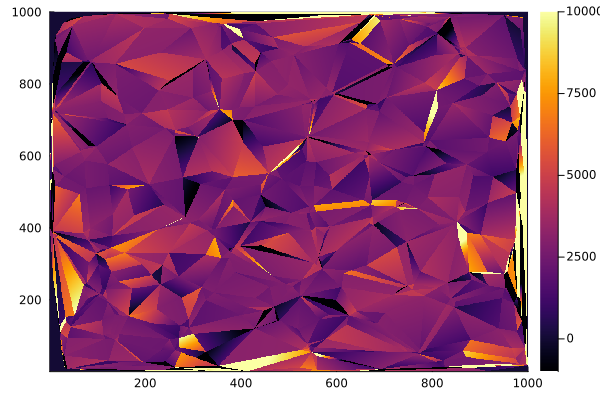

In [35]:
heatmap(dens,clim=(-1000,10000))

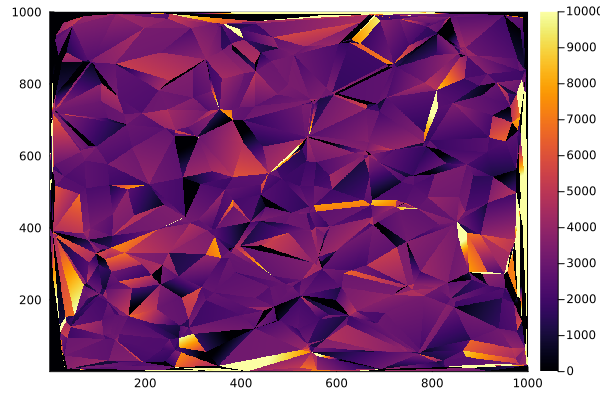

In [36]:
heatmap(dens,clim=(0,10000))

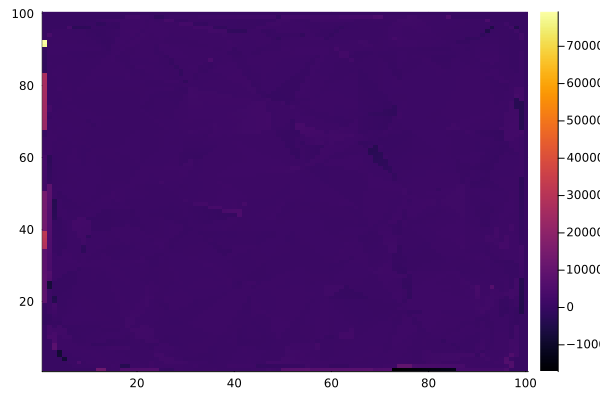

In [11]:
heatmap(dens)

Manual WeightsSVector{3, Float64}[[0.5457990217138525, 0.7551411373580095, 0.8047108740504124], [0.45824785147594815, 0.14695947105453522, 0.19108399252646313], [0.5457990217138525, 0.7551411373580095, 0.8047108740504124], [0.5281265259470468, 0.2886398690245232, 0.9210180201468886], [0.5502345081188638, 0.4226269777969993, 0.8558729634389876], [0.45824785147594815, 0.14695947105453522, 0.19108399252646313], [0.612017654941494, 0.07458959296700773, 0.15089089090294105], [0.3779718685075818, 0.04711705104522301, 0.7060357857423806], [0.5281265259470468, 0.2886398690245232, 0.9210180201468886], [0.612017654941494, 0.07458959296700773, 0.15089089090294105], [0.5457990217138525, 0.7551411373580095, 0.8047108740504124], [0.45824785147594815, 0.14695947105453522, 0.19108399252646313], [0.5502345081188638, 0.4226269777969993, 0.8558729634389876], [0.9158850755797828, 0.6529530623191128, 0.736266336278688], [0.5281265259470468, 0.2886398690245232, 0.9210180201468886], [0.5281265259470468, 0.28

Excessive output truncated after 524289 bytes.

], [0.9158850755797828, 0.6529530623191128, 0.736266336278688], [0.5281265259470468, 0.2886398690245232, 0.9210180201468886], [0.5281265259470468, 0.2886398690245232, 0.9210180201468886]]SVector{3, Float64}[[0.5281265259470468, 0.2886398690245232, 0.9210180201468886], [0.5457990217138525, 0.7551411373580095, 0.8047108740504124], [0.5281265259470468, 0.2886398690245232, 0.9210180201468886], [0.5502345081188638, 0.4226269777969993, 0.8558729634389876], [0.5457990217138525, 0.7551411373580095, 0.8047108740504124], [0.612017654941494, 0.07458959296700773, 0.15089089090294105], [0.45824785147594815, 0.14695947105453522, 0.19108399252646313], [0.45824785147594815, 0.14695947105453522, 0.19108399252646313], [0.5502345081188638, 0.4226269777969993, 0.8558729634389876], [0.5281265259470468, 0.2886398690245232, 0.9210180201468886], [0.45824785147594815, 0.14695947105453522, 0.19108399252646313], [0.5457990217138525, 0.7551411373580095, 0.8047108740504124], [0.5457990217138525, 0.7551411373580095

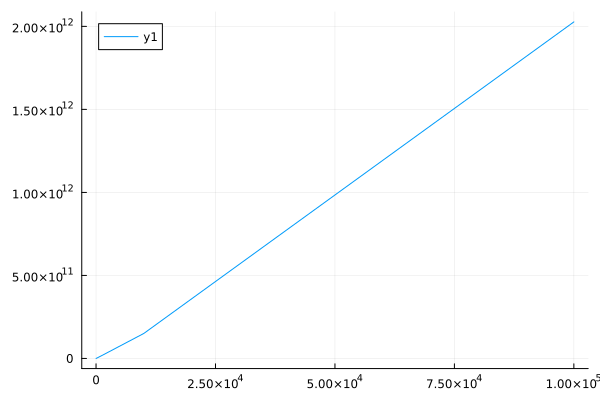

In [113]:
Ns = [10,100,1000,10000,100000]
Tgens = []

for n in Ns
    points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:n]
    bench = @benchmarkable standardEstimator(points3d)
    stats = run(bench)
    push!(Tgens,mean(stats).time)    
end


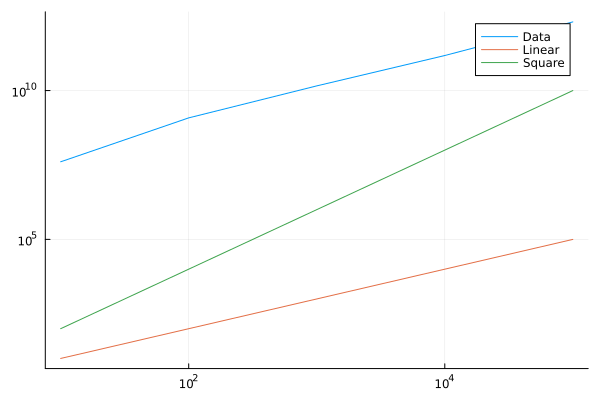

In [135]:
plot(Ns,Tgens,xscale=:log10,yscale=:log10,label="Data")
plot!([Ns[1],Ns[end]],[Ns[1],Ns[end]],xscale=:log10,yscale=:log10,label = "Linear")
plot!([Ns[1],Ns[end]],[Ns[1],Ns[end]] .^2,xscale=:log10,yscale=:log10,label = "Square")

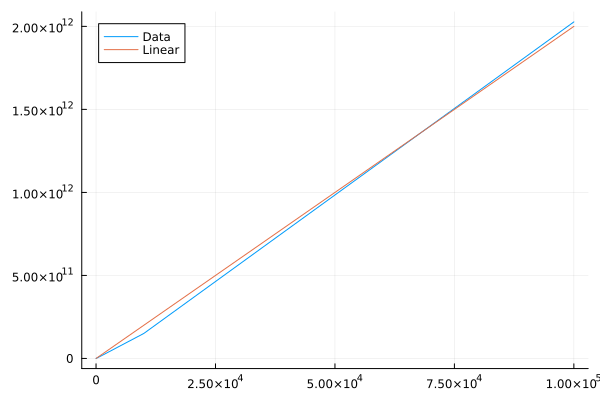

In [ ]:
plot(Ns,Tgens,label="Data",title="Speed Growth",xlabel="Points Tesselated",ylabel = "Nanoseconds")
plot!([Ns[1],Ns[end]],[Ns[1],Ns[end]] .* 20000000,label = "Linear")
#plot!([Ns[1],Ns[end]],[Ns[1],Ns[end]] .^2,label = "Square")


In [24]:
n = 1000
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:n]


1000-element Vector{SVector{3, Float64}}:
 [0.8671590027200555, 0.7650287890189753, 0.3806960539000881]
 [0.5435644366588684, 0.16360910436445408, 0.4484117482135558]
 [0.626079095981915, 0.19415257345842563, 0.33895630152965917]
 [0.04997674436312083, 0.6815036759566059, 0.3879872805049668]
 [0.15132475059670103, 0.582075346958671, 0.9611230993233403]
 [0.9413553303578186, 0.4834553286672818, 0.6499672368814089]
 [0.7260299662872288, 0.40736283927355554, 0.4188550522941612]
 [0.8974146329871918, 0.10585780555682434, 0.9145428892370817]
 [0.2601337818559114, 0.634103749088191, 0.1664958376711757]
 [0.617589597917041, 0.7416374971677325, 0.5257933576648812]
 ⋮
 [0.6560615795770957, 0.4838826099709703, 0.9795171172448605]
 [0.1529229620245819, 0.8744110508915734, 0.9041133538540064]
 [0.06291363676242223, 0.9594125901940412, 0.3753461411809377]
 [0.9123513248582579, 0.2906417724171736, 0.894612225689828]
 [0.15571656985152293, 0.1650026206883023, 0.7374927792622437]
 [0.37859060135200184

In [25]:

bench = @benchmarkable standardEstimator(points3d)
stats = run(bench)

BenchmarkTools.Trial: 1 sample with 1 evaluation per sample.
 Single result which took 20.712 s (0.03% GC) to evaluate,
 with a memory estimate of 85.01 MiB, over 2298726 allocations.

In [36]:
mean(stats)

BenchmarkTools.TrialEstimate: 
  time:             20.712 s
  gctime:           6.539 ms (0.03%)
  memory:           85.01 MiB
  allocs:           2298726

In [27]:
@btime standardEstimator(points3d)

(BVH(BVHNode(9, BVHNode(8, BVHNode(7, BVHNode(6, BVHNode(5, BVHNode(4, BVHNode(3, BVHNode(2, BVHNode(1, BVHLeaf([34, 37, 39, 80, 115, 136, 143, 155, 226, 249  …  1501, 1737, 2636, 2685, 5036, 5673, 5964, 6096, 6097, 6132]), BVHLeaf([34, 37, 39, 54, 79, 80, 102, 106, 115, 136  …  1506, 1648, 1737, 1756, 1781, 2636, 2685, 5329, 5673, 5975])), BVHNode(1, BVHLeaf([34, 37, 80, 136, 143, 155, 343, 348, 360, 446  …  1441, 1501, 1737, 2636, 2685, 3417, 5036, 5964, 6097, 6132]), BVHLeaf([10, 34, 37, 54, 79, 80, 102, 136, 150, 155  …  1441, 1497, 1498, 1501, 1648, 1737, 1781, 1846, 2636, 2685]))), BVHNode(2, BVHNode(1, BVHLeaf([34, 115, 143, 249, 306, 348, 563, 696, 728, 753  …  6063, 6065, 6076, 6077, 6096, 6097, 6098, 6099, 6132, 6325]), BVHLeaf([1, 34, 102, 115, 141, 150, 152, 188, 306, 329  …  1451, 1470, 1472, 1503, 4095, 5329, 5673, 5975, 6008, 6009])), BVHNode(1, BVHLeaf([34, 108, 143, 343, 348, 446, 495, 563, 729, 751  …  1034, 1036, 3417, 5036, 5964, 6063, 6065, 6077, 6097, 6132]), BVHL